# Этап 2 — EDA: разведочный анализ под предиктивный мониторинг

**Постановка (мониторинг, не диагностика).** Мы не «ищем аномалии-поломки», а
оцениваем, **насколько устойчивое отклонение F1 вообще можно отделить от шума и
режима**. EDA готовит почву для трёх слоёв Варианта C: режимной модели «ожидаемого
F1», индикатора здоровья по остатку и прогноза/упреждения.

Что проверяем: (1) насколько F1 постоянна -> какой масштаб сдвигов нужно ловить;
(2) связь F1<->режим -> зачем нужна режимная модель; (3) автокорреляцию -> почему
persistence силён и почему детектор медленный; (4) сегменты/разрывы; (5)
**масштаб сигнала vs шум** (ключевое для раздела ограничений); (6) сезонную
динамику (задел под сезонный конфаунд 2016); (7) **что НЕ видно в данных**.

> Корреляции остатка и гомоскедастичность по переходам здесь НЕ дублируются —
> они посчитаны в под-исследовании (`src/transient_study.py`), сюда — только ссылка.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Корень проекта ищем вверх по дереву (ноутбук запускается из notebooks/).
ROOT = os.getcwd()
while not os.path.isdir(os.path.join(ROOT, "outputs")) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
OUT = os.path.join(ROOT, "outputs")

# Чистая почасовая таблица (этап 1) + остатки слоя 1 (для масштаба шума).
clean = pd.read_csv(os.path.join(OUT, "modero_clean.csv"), parse_dates=["time"])
resid = pd.read_parquet(os.path.join(OUT, "modero_residuals.parquet"))
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("clean:", clean.shape, "| период:", clean.time.min().date(), "->", clean.time.max().date())
print("сегментов:", clean.seg.nunique(), "| переходных часов:",
      int((clean.transient == True).sum()), f"({100*(clean.transient == True).mean():.1f}%)")

clean: (12470, 22) | период: 2015-03-04 -> 2017-01-18
сегментов: 37 | переходных часов: 2259 (18.1%)


## 1. Распределение F1 — насколько параметр постоянен

F1 занимает узкую полосу ~19.3 Гц (sigma~0.016). Любой диагностический сдвиг будет
**мелким** — детектор обязан ловить малые отклонения, а не большие скачки. Это
первый аргумент, почему «голый» прогноз F1 малоинформативен, а важен остаток
относительно ожидаемого режимного уровня.

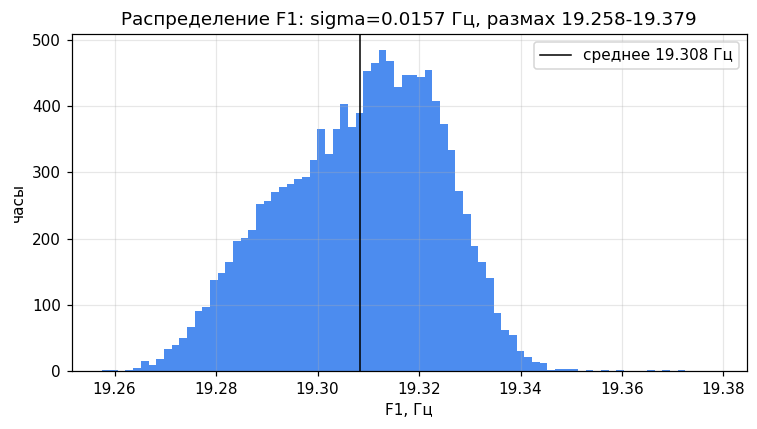

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
# Гистограмма F1: узкая полоса вокруг ~19.3 Гц.
ax.hist(clean["F1"], bins=80, color="#1f6feb", alpha=0.8)
ax.axvline(clean["F1"].mean(), color="k", lw=1, label=f"среднее {clean['F1'].mean():.3f} Гц")
ax.set_xlabel("F1, Гц"); ax.set_ylabel("часы")
ax.set_title(f"Распределение F1: sigma={clean['F1'].std():.4f} Гц, размах "
             f"{clean['F1'].min():.3f}-{clean['F1'].max():.3f}")
ax.legend(); fig.tight_layout()
fig.savefig(os.path.join(OUT, "eda_01_f1_distribution.png"))
plt.show()

## 2. Связь F1 <-> режим — зачем нужна модель «ожидаемого F1»

F1 заметно коррелирует с нагрузкой и температурами (Pr, Tst, Pa) и почти не связана
с частотой вращения Fr (~50 Гц). Значит часть вариации F1 — чисто режимная, и её
нужно «вычесть» режимной моделью `f_reg`, чтобы остаток отражал состояние вала, а
не текущий режим.

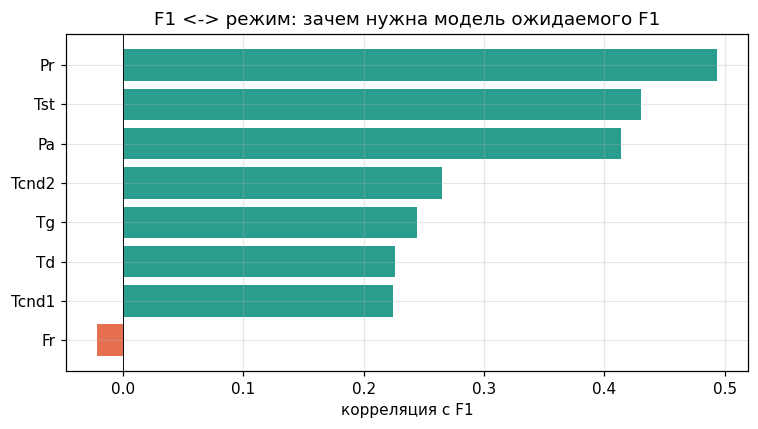

Fr      -0.022
Tcnd1    0.225
Td       0.226
Tg       0.245
Tcnd2    0.265
Pa       0.414
Tst      0.431
Pr       0.494
Name: F1, dtype: float64


In [3]:
drivers = ["Pa", "Pr", "Td", "Tg", "Tst", "Tcnd1", "Tcnd2", "Fr"]
# Корреляция F1 с режимными драйверами — обоснование режимной модели.
corr = clean[["F1"] + drivers].corr()["F1"].drop("F1").sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(corr.index, corr.values, color=["#e76f51" if v < 0 else "#2a9d8f" for v in corr.values])
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("корреляция с F1"); ax.set_title("F1 <-> режим: зачем нужна модель ожидаемого F1")
fig.tight_layout(); fig.savefig(os.path.join(OUT, "eda_02_f1_regime_corr.png"))
plt.show()
print(corr.round(3))

## 3. Автокорреляция F1 — два следствия сразу

Автокорреляция F1 высокая на 1 ч (~0.87) и заметна на суточном лаге (24 ч). Это
объясняет **сразу две вещи**: (а) почему наивный persistence — сильный эталон
прогноза; (б) почему детектор **медленный** — соседние часы почти не несут новой
информации (штраф автокорреляции: эффективных независимых наблюдений намного
меньше, чем часов).

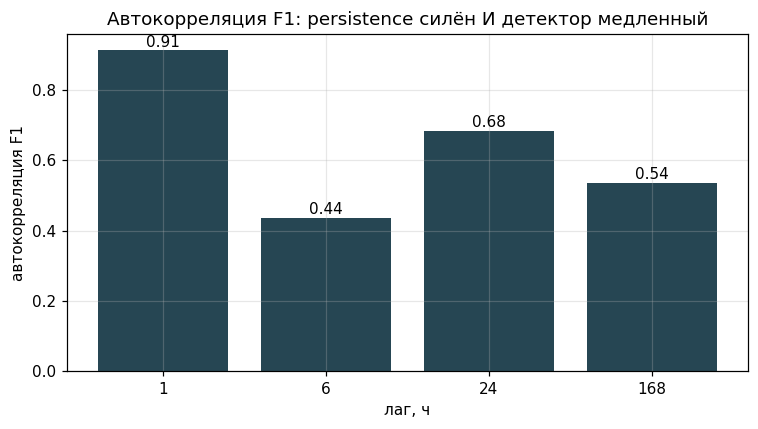

{1: np.float64(0.913), 6: np.float64(0.436), 24: np.float64(0.685), 168: np.float64(0.536)}


In [4]:
lags = [1, 6, 24, 168]
# Автокорреляция считается ВНУТРИ сегментов (сдвиг через разрыв не имеет смысла).
ac = {}
for lag in lags:
    lagged = clean.groupby("seg")["F1"].shift(lag)
    ac[lag] = clean["F1"].corr(lagged)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(l) for l in lags], [ac[l] for l in lags], color="#264653")
for l in lags:
    ax.text(str(l), ac[l] + 0.01, f"{ac[l]:.2f}", ha="center")
ax.set_xlabel("лаг, ч"); ax.set_ylabel("автокорреляция F1")
ax.set_title("Автокорреляция F1: persistence силён И детектор медленный")
fig.tight_layout(); fig.savefig(os.path.join(OUT, "eda_03_autocorr.png"))
plt.show()
print({l: round(v, 3) for l, v in ac.items()})

## 4. Сегменты и разрывы

Ряд почасовой, но с разрывами (>1 ч): режем на непрерывные сегменты и НЕ
интерполируем через дыры. Все лаги/скользящие/CUSUM считаются внутри сегментов.

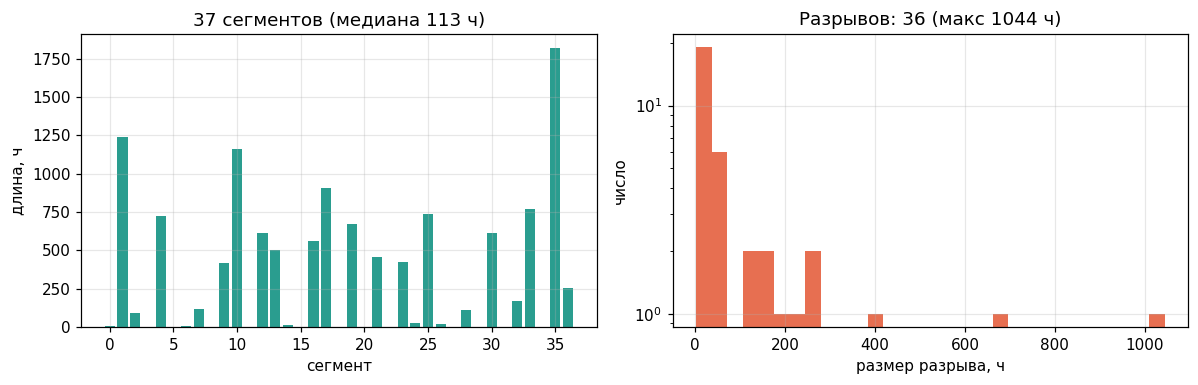

In [5]:
seglen = clean.groupby("seg").size()
gaps = clean["time"].diff()
gap_h = (gaps[gaps != pd.Timedelta(hours=1)].dropna() / pd.Timedelta(hours=1))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
# Слева — длины сегментов, справа — размеры разрывов (часы, лог-шкала).
axes[0].bar(range(len(seglen)), seglen.values, color="#2a9d8f")
axes[0].set_xlabel("сегмент"); axes[0].set_ylabel("длина, ч")
axes[0].set_title(f"{len(seglen)} сегментов (медиана {int(seglen.median())} ч)")
axes[1].hist(gap_h, bins=30, color="#e76f51")
axes[1].set_yscale("log"); axes[1].set_xlabel("размер разрыва, ч"); axes[1].set_ylabel("число")
axes[1].set_title(f"Разрывов: {len(gap_h)} (макс {gap_h.max():.0f} ч)")
fig.tight_layout(); fig.savefig(os.path.join(OUT, "eda_04_segments.png"))
plt.show()

## 5. Масштаб сигнала vs шум — **ключевой график**

Главный тезис ограничений: **искомый сигнал сопоставим с шумом**. Здесь видно
напрямую — распределение остатка f_reg (sigma~0.012 Гц) и амплитуды синтетических
сценариев дрейфа (0.005-0.015 Гц) лежат **в одном масштабе**. Когда сдвиг не больше
шума, его нельзя поймать быстро — отсюда задержки в недели (предел сигнал/шум, а не
дефект кода).

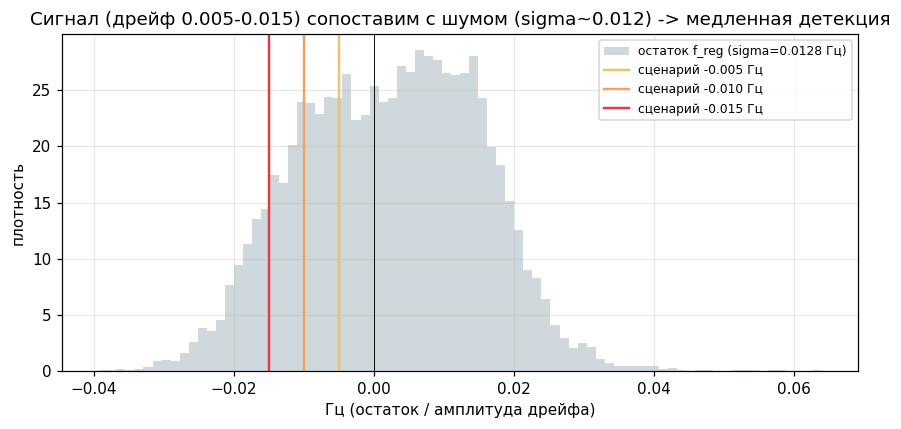

sigma остатка = 0.0128 Гц; сценарии 0.005-0.015 Гц -> сигнал/шум ~ 0.39-1.17


In [6]:
r = resid["resid_gbm"].dropna()
sigma = r.std()
fig, ax = plt.subplots(figsize=(8, 4))
# Распределение остатка (шум) + амплитуды синтетических сценариев (сигнал).
ax.hist(r, bins=80, density=True, color="#cfd8dc", label=f"остаток f_reg (sigma={sigma:.4f} Гц)")
for amp, c in zip([0.005, 0.010, 0.015], ["#e9c46a", "#f4a261", "#e63946"]):
    ax.axvline(-amp, color=c, lw=1.6, label=f"сценарий -{amp:.3f} Гц")
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("Гц (остаток / амплитуда дрейфа)"); ax.set_ylabel("плотность")
ax.set_title("Сигнал (дрейф 0.005-0.015) сопоставим с шумом (sigma~0.012) -> медленная детекция")
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig(os.path.join(OUT, "eda_05_signal_vs_noise.png"))
plt.show()
print(f"sigma остатка = {sigma:.4f} Гц; сценарии 0.005-0.015 Гц -> сигнал/шум ~ "
      f"{0.005/sigma:.2f}-{0.015/sigma:.2f}")

## 6. Сезонная динамика — задел под сезонный конфаунд

F1 и температуры охлаждения (Tcnd1/2) имеют годовой ход. Это важно показать
**заранее**: единственный реальный эпизод дрейфа (лето 2016) совпал с жаркой
охлаждающей водой, поэтому полностью отделить «здоровье» от сезона в одном эпизоде
нельзя. Сезон — не сюрприз постфактум, а заранее видимое свойство данных.

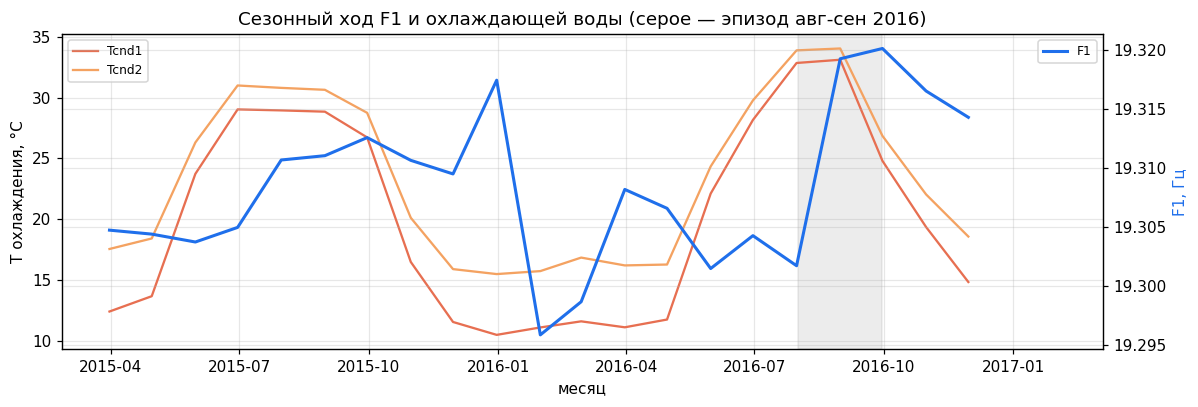

In [7]:
m = clean.set_index("time")
mon = m.resample("ME").agg(F1=("F1", "mean"), Tcnd1=("Tcnd1", "mean"), Tcnd2=("Tcnd2", "mean"))
fig, ax1 = plt.subplots(figsize=(11, 3.8))
# Помесячное среднее F1 (правая ось) и температур охлаждения (левая ось).
ax1.plot(mon.index, mon["Tcnd1"], color="#e76f51", label="Tcnd1")
ax1.plot(mon.index, mon["Tcnd2"], color="#f4a261", label="Tcnd2")
ax1.set_ylabel("T охлаждения, °C"); ax1.set_xlabel("месяц")
ax2 = ax1.twinx()
ax2.plot(mon.index, mon["F1"], color="#1f6feb", lw=2, label="F1")
ax2.set_ylabel("F1, Гц", color="#1f6feb")
ax1.axvspan(pd.Timestamp("2016-08-01"), pd.Timestamp("2016-09-30"), color="gray", alpha=0.15)
ax1.set_title("Сезонный ход F1 и охлаждающей воды (серое — эпизод авг-сен 2016)")
ax1.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
fig.tight_layout(); fig.savefig(os.path.join(OUT, "eda_06_seasonal.png"))
plt.show()

## 7. Что НЕ видно в данных (честный подраздел)

Прямой задел под раздел «Ограничения» и под тезис «один F1 — не диагноз»:

- **Нет меток отказов** — ни одной размеченной аварии/деградации; детектор нельзя
  обучить/проверить на реальных отказах (отсюда валидация синтетикой).
- **Нет других физических признаков** — амплитуд собственных частот, демпфирования,
  статической закрутки, НДС, спектров. Есть только F1 -> можно сказать «что-то
  изменилось», но не «что именно».
- **Агрегат работает непрерывно** — нет пусков/остановов (Pa никогда не падает к
  нулю), поэтому переходные режимы — только смены нагрузки, а не запуски машины.

In [8]:
# Подтверждение непрерывной работы: минимум активной мощности заметно выше нуля.
print(f"Pa: min={clean['Pa'].min():.1f} МВт, max={clean['Pa'].max():.1f} МВт "
      f"-> агрегат не останавливается (нет пусков/остановов)")
print("Меток отказов в данных: нет. Других модальностей (амплитуды/демпфирование/НДС): нет.")
print("Доступен один диагностический параметр: F1.")

Pa: min=16.3 МВт, max=301.8 МВт -> агрегат не останавливается (нет пусков/остановов)
Меток отказов в данных: нет. Других модальностей (амплитуды/демпфирование/НДС): нет.
Доступен один диагностический параметр: F1.


## Выводы EDA (в терминах мониторинга)

1. **F1 почти постоянна** (sigma~0.016 Гц, полоса ~19.3) -> задача — отделять
   **малые** устойчивые отклонения, а не искать большие аномалии.
2. **Часть вариации F1 — режимная** (связь с Pr/Tst/Pa) -> нужна модель ожидаемого
   F1; остаток относительно неё и есть предмет мониторинга.
3. **Высокая автокорреляция (0.87@1ч)** одновременно делает persistence сильным
   эталоном и **ограничивает скорость** детектора (штраф автокорреляции).
4. **Сигнал сопоставим с шумом** (дрейф 0.005-0.015 vs sigma~0.012 Гц) -> честный
   предел: надёжная детекция медленная (недели), ускорение — только через более
   чистый остаток (меньше sigma) или более сильный дрейф.
5. **Сезонный ход** F1/охлаждения виден заранее -> эпизод 2016 интерпретируем с
   поправкой на сезон, а не как чистый «сигнал здоровья».
6. **Данные ограничены одним параметром без меток отказов** -> проект — health-
   индикатор раннего предупреждения, а не диагностика; «стоит присмотреться»,
   а не «вал сломан».

> Дальше: остаток считается в слое 1 (`f_reg`), его поведение steady/transient и
> корреляции — в `src/transient_study.py` (здесь не дублируется).